In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import time
import random
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

# pip install timm scikit-learn matplotlib jika belum
import timm
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import itertools

d:\All Hands On Semester 7\VisionTransformer-Comparison\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ============================================================
# 2. CONFIGURATION & HYPERPARAMETERS
# ============================================================

# Path dataset

DATA_DIR = "dataset3"

NUM_CLASSES = 5
BATCH_SIZE = 32               # gunakan 16, 32
NUM_EPOCHS = 15
LEARNING_RATE = 1e-5 # gunakan 1e-4, 1e-5 
# Early Stopping config
EARLY_STOPPING = True        # aktifkan atau nonaktifkan
PATIENCE = 5                 # berapa epoch tanpa perbaikan sebelum stop
MIN_DELTA = 0.0              # improvement minimal

# Split proporsi
TEST_RATIO = 0.15
VAL_RATIO = 0.15

# ---- MODEL & RUN CONFIG (CHANGEABLE) ----
MODEL_TAG = "DEiT"               # ganti "Swin" kalau pakai Swin
TIMM_MODEL_NAME = "deit_small_patch16_224"  # ganti misal: "swin_tiny_patch4_window7_224 / deit_small_patch16_224"
RUN_ID = "training2"             # ganti "training2", dst untuk eksperimen lain

RUN_NAME = f"{RUN_ID}_{MODEL_TAG}"

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Seed biar konsisten
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Using device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


In [3]:
# ============================================================
# 3. OUTPUT DIRECTORY SETUP
# ============================================================

BASE_DIRS = {
    "best_model": "best_model",
    "confmat": "confmatrics_result",
    "plots": "plot_result",
    "result_img": "result_image",
}

# bikin subfolder per run, misal: best_model/training1_DEiT
RUN_DIRS = {}
for key, base in BASE_DIRS.items():
    run_dir = os.path.join(base, RUN_NAME)
    os.makedirs(run_dir, exist_ok=True)
    RUN_DIRS[key] = run_dir

In [4]:
# File-path penting
BEST_MODEL_PATH = os.path.join(RUN_DIRS["best_model"], "best_model.pth")
TRAIN_LOG_PATH = os.path.join(RUN_DIRS["best_model"], "training_log.txt")
METRICS_PATH = os.path.join(RUN_DIRS["best_model"], "metrics_result.txt")
INFERENCE_PATH = os.path.join(RUN_DIRS["best_model"], "inference_time.txt")

CONF_RAW_PATH = os.path.join(RUN_DIRS["confmat"], "confmat_raw.png")
CONF_NORM_PATH = os.path.join(RUN_DIRS["confmat"], "confmat_normalized.png")

LOSS_PLOT_PATH = os.path.join(RUN_DIRS["plots"], "loss_curve.png")
ACC_PLOT_PATH = os.path.join(RUN_DIRS["plots"], "accuracy_curve.png")

RESULT_IMAGE_PATH = os.path.join(RUN_DIRS["result_img"], "predictions.png")

In [5]:
# ============================================================
# 4. DATASET LOADING & TRANSFORMS
# ============================================================

# Base dataset 
base_dataset = datasets.ImageFolder(root=DATA_DIR)
class_names = base_dataset.classes
print("Classes:", class_names)
print("Total images:", len(base_dataset))

# Transform TRAIN (augmentasi)
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225)),
])

# Transform VAL/TEST (tanpa augmentasi heavy)
eval_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225)),
])

# ---- Split train / val / test ----
num_samples = len(base_dataset)
indices = list(range(num_samples))
random.shuffle(indices)

num_test = int(TEST_RATIO * num_samples)
num_val = int(VAL_RATIO * num_samples)
num_train = num_samples - num_test - num_val

train_indices = indices[:num_train]
val_indices = indices[num_train:num_train + num_val]
test_indices = indices[num_train + num_val:]

print(f"Train samples: {len(train_indices)}")
print(f"Val samples  : {len(val_indices)}")
print(f"Test samples : {len(test_indices)}")


Classes: ['cat', 'dog', 'elephant', 'horse', 'lion']
Total images: 12499
Train samples: 8751
Val samples  : 1874
Test samples : 1874


In [6]:
# Dataset dengan transform berbeda
train_dataset = Subset(
    datasets.ImageFolder(root=DATA_DIR, transform=train_transform),
    train_indices
)
val_dataset = Subset(
    datasets.ImageFolder(root=DATA_DIR, transform=eval_transform),
    val_indices
)
test_dataset = Subset(
    datasets.ImageFolder(root=DATA_DIR, transform=eval_transform),
    test_indices
)

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


In [7]:
# ============================================================
# 5. MODEL DEFINITION (DEiT / SWIN via TIMM)
# ============================================================

def create_model(num_classes: int):
    """
    Membuat model Vision Transformer (DEiT atau Swin)
    berdasarkan TIMM_MODEL_NAME.
    """
    model = timm.create_model(
        TIMM_MODEL_NAME,
        pretrained=True,
        num_classes=num_classes
    )
    return model

model = create_model(NUM_CLASSES).to(device)

In [8]:
# ============================================================
# 6. MODEL PARAM SUMMARY (PARAM & SIZE MB)
# ============================================================

def summarize_model_parameters(model, tag: str):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    non_trainable_params = total_params - trainable_params
    model_size_mb = total_params * 4 / (1024 ** 2)  # float32 -> 4 bytes

    summary_str = []
    summary_str.append(f"===== MODEL PARAMETER SUMMARY ({tag}) =====")
    summary_str.append(f"Total parameters        : {total_params:,}")
    summary_str.append(f"Trainable parameters    : {trainable_params:,}")
    summary_str.append(f"Non-trainable parameters: {non_trainable_params:,}")
    summary_str.append(f"Estimated model size    : {model_size_mb:.2f} MB")
    summary_str.append("==========================================")

    print("\n".join(summary_str))
    return "\n".join(summary_str) + "\n"

param_summary_text = summarize_model_parameters(model, MODEL_TAG)

===== MODEL PARAMETER SUMMARY (DEiT) =====
Total parameters        : 21,667,589
Trainable parameters    : 21,667,589
Non-trainable parameters: 0
Estimated model size    : 82.66 MB


In [9]:
# ============================================================
# 7. LOSS & OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

In [10]:
# ============================================================
# 8. TRAINING & VALIDATION LOOPS
# ============================================================

def train_one_epoch(model, loader, optimizer, criterion, device, epoch, num_epochs):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for batch_idx, (inputs, labels) in enumerate(loader):
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Forward
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Statistik
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)

        # Print progress per batch (iterasi)
        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Iter [{batch_idx+1}/{len(loader)}] "
              f"Loss: {loss.item():.4f}")

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc


def validate_one_epoch(model, loader, criterion, device, epoch, num_epochs):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for batch_idx, (inputs, labels) in enumerate(loader):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            running_correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    print(f"[VALIDATION] Epoch [{epoch+1}/{num_epochs}] "
          f"Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")
    return epoch_loss, epoch_acc

def train_model(model, train_loader, val_loader, optimizer, criterion, device, num_epochs, log_file_path):
    """
    Training loop dengan:
    - logging ke txt (log_file_path)
    - early stopping berbasis validation loss
    - simpan best model ke BEST_MODEL_PATH
    """

    best_val_loss = float("inf")
    best_val_acc = 0.0
    epochs_no_improve = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    log_lines = []

    # OPTIONAL: kalau di atas lu ada param_summary_text, boleh di-append di sini
    # contoh:
    # log_lines.append(param_summary_text.strip())
    # log_lines.append("")
    
    for epoch in range(num_epochs):
        print("=" * 60)
        print(f"Epoch {epoch+1}/{num_epochs}")
        print("-" * 60)
        log_lines.append("=" * 60)
        log_lines.append(f"Epoch {epoch+1}/{num_epochs}")
        log_lines.append("-" * 60)

        # -------- TRAIN --------
        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, device, epoch, num_epochs
        )

        # -------- VALIDATION --------
        val_loss, val_acc = validate_one_epoch(
            model, val_loader, criterion, device, epoch, num_epochs
        )

        msg_epoch = (f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}\n"
                     f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
        print(msg_epoch)
        log_lines.append(msg_epoch)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        # -------- EARLY STOPPING LOGIC (berdasarkan val_loss) --------
        if EARLY_STOPPING:
            if val_loss + MIN_DELTA < best_val_loss:
                # ada improvement signifikan
                best_val_loss = val_loss
                best_val_acc = val_acc
                epochs_no_improve = 0

                # simpan best model tiap ada improvement
                torch.save(model.state_dict(), BEST_MODEL_PATH)
                msg_improve = f">> Improved val_loss to {best_val_loss:.4f}, model saved."
                print(msg_improve)
                log_lines.append(msg_improve)
            else:
                # tidak membaik
                epochs_no_improve += 1
                msg_no_imp = f">> No improvement in val_loss for {epochs_no_improve} epoch(s)."
                print(msg_no_imp)
                log_lines.append(msg_no_imp)

            # cek patience
            if epochs_no_improve >= PATIENCE:
                msg_es = f">> Early stopping triggered at epoch {epoch+1}."
                print(msg_es)
                log_lines.append(msg_es)
                break

        else:
            # mode lama: hanya simpan best berdasarkan val_acc
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                torch.save(model.state_dict(), BEST_MODEL_PATH)
                msg_improve = f">> Saved best model with val_acc: {best_val_acc:.4f}"
                print(msg_improve)
                log_lines.append(msg_improve)

    final_msg = f"Training complete. Best val_loss: {best_val_loss:.4f}, best val_acc: {best_val_acc:.4f}"
    print(final_msg)
    log_lines.append(final_msg)

    # tulis log ke file txt
    with open(log_file_path, "w") as f:
        for line in log_lines:
            f.write(line + "\n")

    return history


In [11]:
# ============================================================
# 9. PLOTTING LEARNING CURVES & SAVE
# ============================================================

def plot_training_curves(history, loss_path=None, acc_path=None):
    epochs = range(1, len(history["train_loss"]) + 1)

    # Loss
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Training & Validation Loss ({RUN_NAME})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    if loss_path is not None:
        plt.savefig(loss_path)
    plt.show()
    plt.close()

    # Accuracy
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["val_acc"], label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Training & Validation Accuracy ({RUN_NAME})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    if acc_path is not None:
        plt.savefig(acc_path)
    plt.show()
    plt.close()

In [12]:
# ============================================================
# 10. CONFUSION MATRIX & METRICS (SIMPAN + PRINT)
# ============================================================

def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion Matrix', cmap=plt.cm.Blues, save_path=None):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(6, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha="right")
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.

    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(
            j, i, format(cm[i, j], fmt),
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black"
        )

    plt.tight_layout()
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    if save_path is not None:
        plt.savefig(save_path)
    plt.show()
    plt.close()


def evaluate_model(model, loader, device, class_names, metrics_path, conf_raw_path, conf_norm_path):
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    cm = confusion_matrix(all_labels, all_preds)

    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    mean_per_class_acc = per_class_acc.mean()

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average=None, labels=range(len(class_names))
    )

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='macro'
    )

    overall_acc = accuracy_score(all_labels, all_preds)

    # print + simpan ke file
    lines = []
    lines.append(f"===== METRICS RESULT ({RUN_NAME}) =====")
    lines.append("Per-class metrics:")
    for idx, cls in enumerate(class_names):
        lines.append(f"Class: {cls}")
        lines.append(f"  Accuracy : {per_class_acc[idx]:.4f}")
        lines.append(f"  Precision: {precision[idx]:.4f}")
        lines.append(f"  Recall   : {recall[idx]:.4f}")
        lines.append(f"  F1-Score : {f1[idx]:.4f}")

    lines.append("")
    lines.append("Averaged metrics:")
    lines.append(f"Overall Accuracy (global)       : {overall_acc:.4f}")
    lines.append(f"Mean Per-Class Accuracy         : {mean_per_class_acc:.4f}")
    lines.append(f"Macro Precision (avg per class) : {precision_macro:.4f}")
    lines.append(f"Macro Recall (avg per class)    : {recall_macro:.4f}")
    lines.append(f"Macro F1-Score (avg per class)  : {f1_macro:.4f}")
    lines.append("=======================================")

    txt = "\n".join(lines)
    print(txt)

    with open(metrics_path, "w") as f:
        f.write(txt + "\n")

    # plot & simpan confmat
    plot_confusion_matrix(cm, class_names, normalize=False,
                          title=f"Confusion Matrix (Raw) - {RUN_NAME}",
                          save_path=conf_raw_path)

    plot_confusion_matrix(cm, class_names, normalize=True,
                          title=f"Confusion Matrix (Normalized) - {RUN_NAME}",
                          save_path=conf_norm_path)

In [13]:
# ============================================================
# 11. INFERENCE TIME MEASUREMENT (SAVE & PRINT)
# ============================================================

def measure_inference_time(model, loader, device, save_path, num_warmup_batches=2):
    model.eval()

    with torch.no_grad():
        for batch_idx, (inputs, _) in enumerate(loader):
            inputs = inputs.to(device)
            _ = model(inputs)
            if batch_idx + 1 >= num_warmup_batches:
                break

    total_images = 0
    start_time = time.time()

    with torch.no_grad():
        for inputs, _ in loader:
            inputs = inputs.to(device)
            _ = model(inputs)
            total_images += inputs.size(0)

    end_time = time.time()
    total_time_sec = end_time - start_time

    total_time_ms = total_time_sec * 1000.0
    avg_time_per_image_ms = (total_time_sec / total_images) * 1000.0
    throughput = total_images / total_time_sec

    lines = []
    lines.append(f"===== INFERENCE TIME ({RUN_NAME}) =====")
    lines.append(f"Total test images          : {total_images}")
    lines.append(f"Total inference time       : {total_time_ms:.2f} ms")
    lines.append(f"Average time per image     : {avg_time_per_image_ms:.4f} ms/image")
    lines.append(f"Throughput                 : {throughput:.2f} images/second")
    lines.append("=======================================")

    txt = "\n".join(lines)
    print(txt)

    with open(save_path, "w") as f:
        f.write(txt + "\n")

In [14]:
# ============================================================
# 12. VISUALISASI SAMPLE PREDIKSI & SAVE
# ============================================================

def visualize_predictions(model, loader, class_names, num_images, save_path):
    model.eval()
    images_shown = 0

    plt.figure(figsize=(14, 8))

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for i in range(inputs.size(0)):
                if images_shown >= num_images:
                    plt.tight_layout()
                    if save_path is not None:
                        plt.savefig(save_path)
                    plt.show()
                    plt.close()
                    return

                img = inputs[i].cpu().clone()

                # unnormalize
                mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
                std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
                img = img * std + mean
                img = torch.clamp(img, 0, 1)

                label = labels[i].item()
                pred = preds[i].item()
                correct = (label == pred)

                plt.subplot(2, num_images // 2, images_shown + 1)
                np_img = img.numpy().transpose((1, 2, 0))
                plt.imshow(np_img)
                color = "green" if correct else "red"
                plt.title(f"Pred: {class_names[pred]}\nTrue: {class_names[label]}", color=color)
                plt.axis("off")

                images_shown += 1

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path)
    plt.show()
    plt.close()

Epoch 1/15
------------------------------------------------------------
Epoch [1/15] Iter [1/274] Loss: 1.4636
Epoch [1/15] Iter [2/274] Loss: 1.4552
Epoch [1/15] Iter [3/274] Loss: 1.4553
Epoch [1/15] Iter [4/274] Loss: 1.4908
Epoch [1/15] Iter [5/274] Loss: 1.3692
Epoch [1/15] Iter [6/274] Loss: 1.3900
Epoch [1/15] Iter [7/274] Loss: 1.3377
Epoch [1/15] Iter [8/274] Loss: 1.4261
Epoch [1/15] Iter [9/274] Loss: 1.3276
Epoch [1/15] Iter [10/274] Loss: 1.1754
Epoch [1/15] Iter [11/274] Loss: 1.2633
Epoch [1/15] Iter [12/274] Loss: 1.1556
Epoch [1/15] Iter [13/274] Loss: 1.2468
Epoch [1/15] Iter [14/274] Loss: 1.2284
Epoch [1/15] Iter [15/274] Loss: 1.1865
Epoch [1/15] Iter [16/274] Loss: 1.1491
Epoch [1/15] Iter [17/274] Loss: 1.0559
Epoch [1/15] Iter [18/274] Loss: 1.1477
Epoch [1/15] Iter [19/274] Loss: 1.0249
Epoch [1/15] Iter [20/274] Loss: 0.9885
Epoch [1/15] Iter [21/274] Loss: 1.0148
Epoch [1/15] Iter [22/274] Loss: 0.9344
Epoch [1/15] Iter [23/274] Loss: 1.0640
Epoch [1/15] Iter

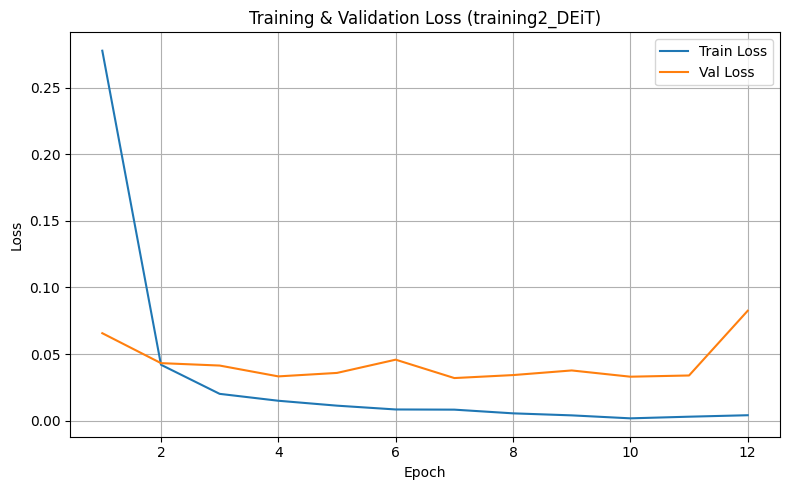

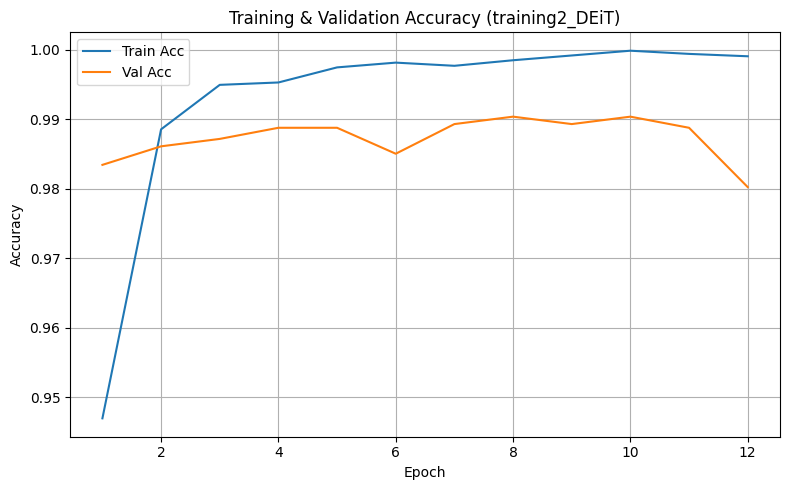

C:\Users\Lenovo Legion\AppData\Local\Temp\ipykernel_2524\3976450295.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(BEST_MODEL_PATH, ma

Loaded best model from best_model\training2_DEiT\best_model.pth for evaluation & inference.
===== METRICS RESULT (training2_DEiT) =====
Per-class metrics:
Class: cat
  Accuracy : 1.0000
  Precision: 1.0000
  Recall   : 1.0000
  F1-Score : 1.0000
Class: dog
  Accuracy : 1.0000
  Precision: 1.0000
  Recall   : 1.0000
  F1-Score : 1.0000
Class: elephant
  Accuracy : 0.9843
  Precision: 0.9690
  Recall   : 0.9843
  F1-Score : 0.9766
Class: horse
  Accuracy : 0.9839
  Precision: 0.9892
  Recall   : 0.9839
  F1-Score : 0.9866
Class: lion
  Accuracy : 0.9759
  Precision: 0.9864
  Recall   : 0.9759
  F1-Score : 0.9811

Averaged metrics:
Overall Accuracy (global)       : 0.9888
Mean Per-Class Accuracy         : 0.9888
Macro Precision (avg per class) : 0.9889
Macro Recall (avg per class)    : 0.9888
Macro F1-Score (avg per class)  : 0.9889


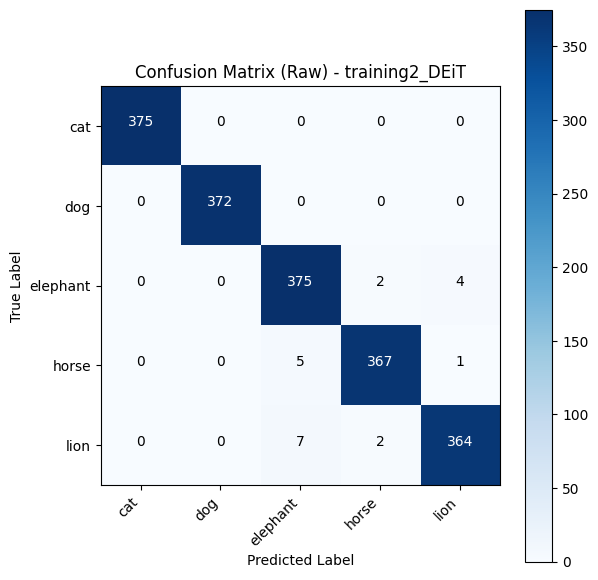

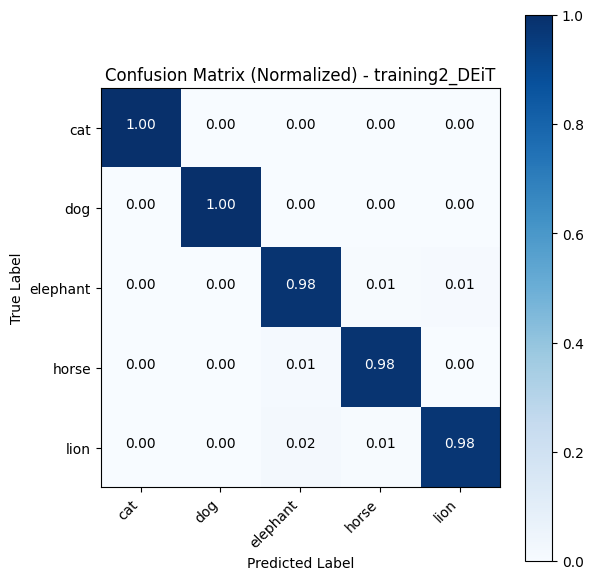

===== INFERENCE TIME (training2_DEiT) =====
Total test images          : 1874
Total inference time       : 6087.82 ms
Average time per image     : 3.2486 ms/image
Throughput                 : 307.83 images/second


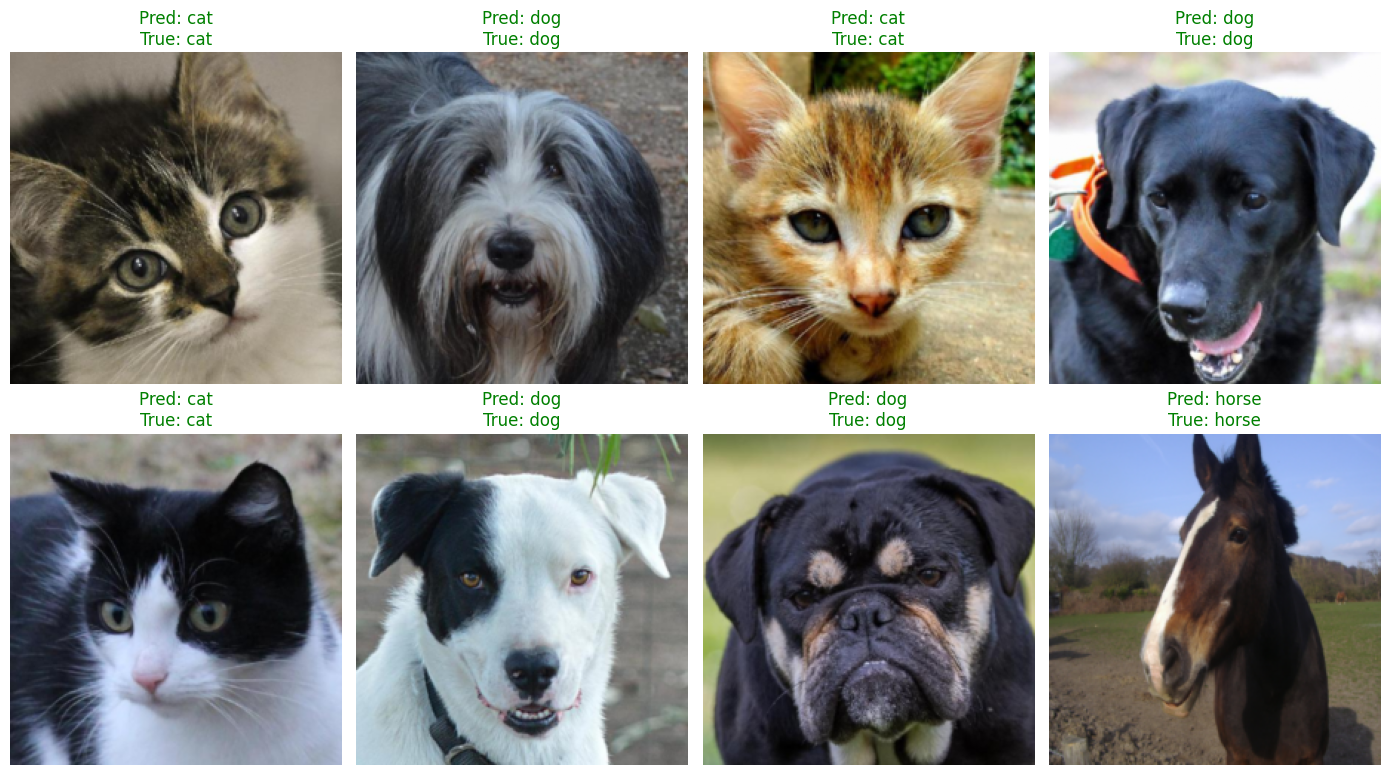

In [15]:
# ============================================================
# 13. MAIN EXECUTION
# ============================================================

if __name__ == "__main__":
    # ---- TRAINING ----
    history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        num_epochs=NUM_EPOCHS,
        log_file_path=TRAIN_LOG_PATH
    )

    # ---- PLOT & SAVE LEARNING CURVES ----
    plot_training_curves(history, loss_path=LOSS_PLOT_PATH, acc_path=ACC_PLOT_PATH)

    # ---- LOAD BEST MODEL ----
    if os.path.exists(BEST_MODEL_PATH):
        model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
        print(f"Loaded best model from {BEST_MODEL_PATH} for evaluation & inference.")

    # ---- EVALUATION (TEST SET) ----
    evaluate_model(
        model=model,
        loader=test_loader,
        device=device,
        class_names=class_names,
        metrics_path=METRICS_PATH,
        conf_raw_path=CONF_RAW_PATH,
        conf_norm_path=CONF_NORM_PATH
    )

    # ---- INFERENCE TIME ----
    measure_inference_time(
        model=model,
        loader=test_loader,
        device=device,
        save_path=INFERENCE_PATH
    )

    # ---- VISUALIZE & SAVE SAMPLE PREDICTIONS ----
    visualize_predictions(
        model=model,
        loader=test_loader,
        class_names=class_names,
        num_images=8,
        save_path=RESULT_IMAGE_PATH
    )